
# 03. Experimentación y Selección de Modelos (Versión mejorada)

En este notebook se entrena, compara y ajusta un conjunto de modelos de regresión para predecir `median_house_value` usando el dataset limpio y enriquecido generado en el Notebook 2.

## Objetivos
1. Cargar el dataset preprocesado.
2. Separar variables predictoras y variable objetivo.
3. Dividir los datos en **entrenamiento, validación y prueba**.
4. Reservar **1 observación** del conjunto de validación para una prueba individual del modelo.
5. Comparar modelos base usando validación cruzada en entrenamiento.
6. Ajustar los modelos más prometedores con búsqueda de hiperparámetros.
7. Seleccionar el mejor modelo usando el conjunto de validación.
8. Evaluar el modelo final en el conjunto de prueba.
9. Reportar métricas en valores absolutos **y en porcentaje**.


In [3]:

# Importa pandas para cargar y manipular el dataset
import pandas as pd

# Importa numpy para operaciones numéricas
import numpy as np

# Importa matplotlib para crear gráficos
import matplotlib.pyplot as plt

# Importa utilidades para dividir datos y validar modelos
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold

# Importa pipelines para encadenar transformaciones y modelos
from sklearn.pipeline import Pipeline

# Importa escalado para modelos sensibles a magnitud de variables
from sklearn.preprocessing import StandardScaler

# Importa métricas de evaluación para regresión
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Importa modelos base
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Configuración visual básica
plt.rcParams["figure.figsize"] = (10, 6)
plt.style.use("default")


## 1. Carga del dataset preprocesado

In [4]:

# Carga el archivo generado en el Notebook 2 desde la misma carpeta del notebook
datos_modelado = pd.read_csv("./housing_preparado.csv")

# Muestra las primeras filas para validar la carga
display(datos_modelado.head())

# Muestra dimensiones y tipos
print("Dimensiones:", datos_modelado.shape)
display(datos_modelado.info())


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,is_age_capped,is_price_capped,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,rooms_per_person,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,False,False,True,False,6.984127,2.732919,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,False,False,True,False,6.238137,2.956685,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,1,0,False,False,True,False,8.288136,2.957661,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,1,0,False,False,True,False,5.817352,2.283154,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,1,0,False,False,True,False,6.281853,2.879646,0.172096


Dimensiones: (20640, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   is_age_capped               20640 non-null  int64  
 10  is_price_capped             20640 non-null  int64  
 11  ocean_proximity_INLAND      20640 non-null  bool   
 12  ocean_proximity_ISLAND      20640 non-null  bool   
 13  ocean_

None

## 2. Separación de variables predictoras y variable objetivo

In [5]:

# Define la variable objetivo que se desea predecir
objetivo = "median_house_value"

# Construye la matriz de características eliminando la variable objetivo
X = datos_modelado.drop(columns=[objetivo])

# Construye el vector objetivo
y = datos_modelado[objetivo]

# Muestra dimensiones
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

# Muestra nombres de columnas predictoras
display(X.columns.tolist())


Dimensión de X: (20640, 17)
Dimensión de y: (20640,)


['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'is_age_capped',
 'is_price_capped',
 'ocean_proximity_INLAND',
 'ocean_proximity_ISLAND',
 'ocean_proximity_NEAR BAY',
 'ocean_proximity_NEAR OCEAN',
 'rooms_per_household',
 'rooms_per_person',
 'bedrooms_per_room']


## 3. División en entrenamiento, validación y prueba

Se realiza una división en tres partes:

- **Entrenamiento**: para ajustar modelos y hacer validación cruzada.
- **Validación**: para comparar candidatos ajustados y elegir el mejor.
- **Prueba**: para medir el desempeño final con datos no vistos.

Además, se separa **una sola observación** del conjunto de validación para hacer una prueba individual de predicción.


In [6]:

# Primera división: entrenamiento (70%) y temporal (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Segunda división: validación (15%) y prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Reserva una sola observación del conjunto de validación para prueba individual
X_val_modelo = X_val.iloc[:-1].copy()
y_val_modelo = y_val.iloc[:-1].copy()

X_val_1 = X_val.iloc[[-1]].copy()
y_val_1 = y_val.iloc[[-1]].copy()

# Muestra dimensiones
print("X_train:", X_train.shape)
print("X_val_modelo:", X_val_modelo.shape)
print("X_val_1:", X_val_1.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val_modelo:", y_val_modelo.shape)
print("y_val_1:", y_val_1.shape)
print("y_test:", y_test.shape)


X_train: (14448, 17)
X_val_modelo: (3095, 17)
X_val_1: (1, 17)
X_test: (3096, 17)
y_train: (14448,)
y_val_modelo: (3095,)
y_val_1: (1,)
y_test: (3096,)


## 4. Definición de métricas auxiliares

In [7]:

# Define una función para calcular métricas de regresión en valor absoluto y porcentaje
def calcular_metricas_regresion(y_real, y_pred):
    # Calcula RMSE
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    # Calcula MAE
    mae = mean_absolute_error(y_real, y_pred)

    # Calcula R2
    r2 = r2_score(y_real, y_pred)

    # Calcula MAPE en porcentaje evitando división por cero
    y_real_array = np.array(y_real)
    y_pred_array = np.array(y_pred)
    mape = np.mean(np.abs((y_real_array - y_pred_array) / np.maximum(np.abs(y_real_array), 1e-8))) * 100

    # Calcula RMSE relativo respecto al promedio del target
    rmse_pct_mean = (rmse / np.mean(y_real_array)) * 100

    # Calcula MAE relativo respecto al promedio del target
    mae_pct_mean = (mae / np.mean(y_real_array)) * 100

    # Devuelve todas las métricas en un diccionario
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "mape_pct": mape,
        "rmse_pct_mean": rmse_pct_mean,
        "mae_pct_mean": mae_pct_mean
    }

# Define un esquema de validación cruzada reproducible
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)


## 5. Modelos base y benchmark robusto

In [8]:

# Define un diccionario con modelos base
modelos = {
    "DummyRegressor": DummyRegressor(strategy="mean"),

    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42))
    ]),

    "RandomForestRegressor": RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        n_jobs=-1
    ),

    "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
        random_state=42,
        max_iter=300
    )
}


In [9]:

# Crea una lista vacía para guardar resultados del benchmark
resultados_benchmark = []

# Recorre cada modelo para evaluar mediante validación cruzada en entrenamiento
for nombre_modelo, modelo in modelos.items():

    # Calcula validación cruzada con varias métricas
    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_kfold,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1,
        return_train_score=False
    )

    # Convierte métricas negativas a positivas
    rmse_scores = -scores["test_rmse"]
    mae_scores = -scores["test_mae"]
    r2_scores = scores["test_r2"]

    # Guarda resultados resumen
    resultados_benchmark.append({
        "modelo": nombre_modelo,
        "rmse_cv_mean": rmse_scores.mean(),
        "rmse_cv_std": rmse_scores.std(),
        "mae_cv_mean": mae_scores.mean(),
        "r2_cv_mean": r2_scores.mean(),
        "rmse_cv_pct_mean": (rmse_scores.mean() / y_train.mean()) * 100,
        "mae_cv_pct_mean": (mae_scores.mean() / y_train.mean()) * 100
    })

# Convierte a DataFrame
benchmark_df = pd.DataFrame(resultados_benchmark)

# Ordena por menor RMSE promedio
benchmark_df = benchmark_df.sort_values(by="rmse_cv_mean", ascending=True).reset_index(drop=True)

# Muestra resultados
display(benchmark_df)


,modelo,rmse_cv_mean,rmse_cv_std,mae_cv_mean,r2_cv_mean,rmse_cv_pct_mean,mae_cv_pct_mean
0,HistGradientBoostingRegressor,41836.440933,1064.704183,27824.869503,0.866444,20.316066,13.511950
1,RandomForestRegressor,44733.750425,905.023693,29359.988552,0.847378,21.723020,14.257414
2,Ridge,62292.507898,2524.298013,45169.940375,0.703990,30.249674,21.934837
3,LinearRegression,62294.484870,2527.374162,45171.126196,0.703971,30.250634,21.935413
4,DummyRegressor,114547.713376,1414.869535,90409.898379,-0.000784,55.625165,43.903675


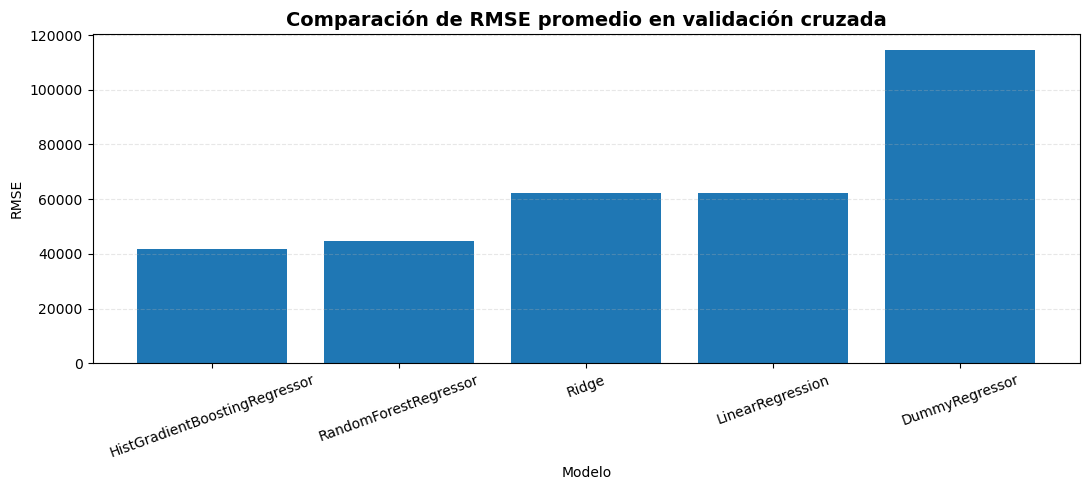

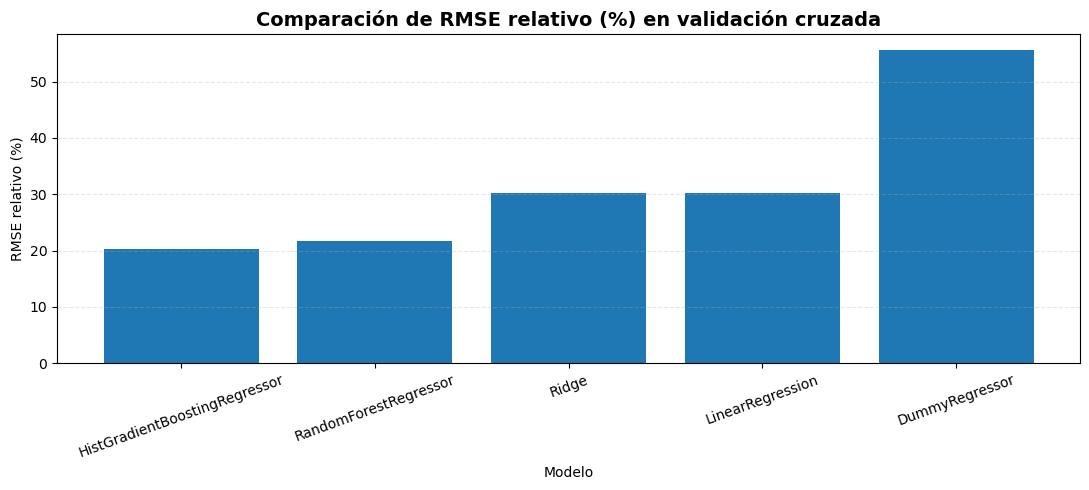

In [10]:

# Crea un gráfico de barras para comparar el RMSE promedio de validación cruzada
plt.figure(figsize=(11, 5))
plt.bar(benchmark_df["modelo"], benchmark_df["rmse_cv_mean"])
plt.title("Comparación de RMSE promedio en validación cruzada", fontsize=14, fontweight="bold")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Crea un gráfico de barras para comparar el RMSE relativo en porcentaje
plt.figure(figsize=(11, 5))
plt.bar(benchmark_df["modelo"], benchmark_df["rmse_cv_pct_mean"])
plt.title("Comparación de RMSE relativo (%) en validación cruzada", fontsize=14, fontweight="bold")
plt.xlabel("Modelo")
plt.ylabel("RMSE relativo (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



## 6. Ajuste fino de los modelos más prometedores

Se ajustan dos candidatos fuertes:
- `RandomForestRegressor`
- `HistGradientBoostingRegressor`

La selección final se hará con base en el **conjunto de validación**.


In [11]:

# Define la cuadrícula para Random Forest
param_grid_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 15, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Crea el objeto GridSearch para Random Forest
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring="neg_root_mean_squared_error",
    cv=cv_kfold,
    n_jobs=-1,
    verbose=0
)

# Ajusta Random Forest sobre entrenamiento
grid_rf.fit(X_train, y_train)

# Muestra mejores hiperparámetros de Random Forest
print("Mejores hiperparámetros RandomForest:")
print(grid_rf.best_params_)
print("Mejor RMSE CV RandomForest:", -grid_rf.best_score_)


KeyboardInterrupt: 

In [ ]:

# Define la cuadrícula para HistGradientBoostingRegressor
param_grid_hgb = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [200, 300, 500],
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [20, 30, 50]
}

# Crea el objeto GridSearch para HistGradientBoostingRegressor
grid_hgb = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_grid=param_grid_hgb,
    scoring="neg_root_mean_squared_error",
    cv=cv_kfold,
    n_jobs=-1,
    verbose=0
)

# Ajusta HistGradientBoosting sobre entrenamiento
grid_hgb.fit(X_train, y_train)

# Muestra mejores hiperparámetros de HistGradientBoosting
print("Mejores hiperparámetros HistGradientBoosting:")
print(grid_hgb.best_params_)
print("Mejor RMSE CV HistGradientBoosting:", -grid_hgb.best_score_)


## 7. Selección del mejor modelo usando el conjunto de validación

In [ ]:

# Obtiene los mejores estimadores ajustados
mejor_rf = grid_rf.best_estimator_
mejor_hgb = grid_hgb.best_estimator_

# Genera predicciones sobre el conjunto de validación
pred_val_rf = mejor_rf.predict(X_val_modelo)
pred_val_hgb = mejor_hgb.predict(X_val_modelo)

# Calcula métricas de validación para ambos modelos
metricas_val_rf = calcular_metricas_regresion(y_val_modelo, pred_val_rf)
metricas_val_hgb = calcular_metricas_regresion(y_val_modelo, pred_val_hgb)

# Construye una tabla comparativa
comparacion_validacion = pd.DataFrame([
    {"modelo": "RandomForest_Ajustado", **metricas_val_rf},
    {"modelo": "HistGradientBoosting_Ajustado", **metricas_val_hgb}
]).sort_values(by="rmse").reset_index(drop=True)

# Muestra comparación
display(comparacion_validacion)


In [ ]:

# Selecciona el mejor modelo según menor RMSE en validación
if metricas_val_rf["rmse"] <= metricas_val_hgb["rmse"]:
    mejor_modelo_nombre = "RandomForest_Ajustado"
    mejor_modelo_final = mejor_rf
else:
    mejor_modelo_nombre = "HistGradientBoosting_Ajustado"
    mejor_modelo_final = mejor_hgb

print("Mejor modelo según validación:", mejor_modelo_nombre)


## 8. Prueba individual con una observación apartada de validación

In [ ]:

# Predice una sola observación apartada del conjunto de validación
pred_1 = mejor_modelo_final.predict(X_val_1)[0]

# Obtiene el valor real
real_1 = y_val_1.iloc[0]

# Calcula error absoluto
error_abs_1 = abs(real_1 - pred_1)

# Calcula error porcentual
error_pct_1 = (error_abs_1 / real_1) * 100

# Construye una tabla resumen
caso_individual = pd.DataFrame({
    "valor_real": [real_1],
    "valor_predicho": [pred_1],
    "error_absoluto": [error_abs_1],
    "error_porcentual_pct": [error_pct_1]
})

display(caso_individual)


## 9. Evaluación final sobre el conjunto de prueba

In [ ]:

# Genera predicciones finales sobre el conjunto de prueba
pred_test_final = mejor_modelo_final.predict(X_test)

# Calcula métricas finales
metricas_test = calcular_metricas_regresion(y_test, pred_test_final)

# Construye tabla final de métricas
metricas_test_df = pd.DataFrame([{
    "modelo": mejor_modelo_nombre,
    **metricas_test
}])

display(metricas_test_df)


In [ ]:

# Crea un gráfico de dispersión entre valores reales y predichos
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test_final, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
plt.title("Valores reales vs valores predichos", fontsize=14, fontweight="bold")
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.tight_layout()
plt.show()


## 10. Comparación final contra el baseline

In [ ]:

# Ajusta el baseline sobre entrenamiento
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

# Predice sobre prueba
pred_test_baseline = baseline.predict(X_test)

# Calcula métricas del baseline
metricas_baseline = calcular_metricas_regresion(y_test, pred_test_baseline)

# Construye comparación final
comparacion_final = pd.DataFrame([
    {"modelo": "DummyRegressor", **metricas_baseline},
    {"modelo": mejor_modelo_nombre, **metricas_test}
]).sort_values(by="rmse").reset_index(drop=True)

display(comparacion_final)


In [ ]:
import os
import joblib

# Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

# Guardar el mejor modelo
joblib.dump(best_model, "models/best_model.pkl")

print("Modelo guardado correctamente en models/best_model.pkl")


## 11. Conclusión sugerida

Completa esta conclusión con los valores que te salgan al ejecutar el notebook.

**Conclusión base:**

A partir del benchmark inicial con validación cruzada, se observó que los modelos basados en árboles superaron al baseline y a los modelos lineales en términos de RMSE y MAE.

Posteriormente, se ajustaron los dos candidatos más prometedores usando búsqueda de hiperparámetros. La selección final se realizó con el conjunto de validación, reservando además una observación individual para comprobar de manera puntual la capacidad predictiva del modelo.

Finalmente, el modelo seleccionado fue evaluado sobre el conjunto de prueba, reportando métricas absolutas y también métricas relativas en porcentaje, lo que permite interpretar el error no solo en unidades monetarias sino también en proporción al valor medio de la variable objetivo.

Si el modelo final mejora claramente al `DummyRegressor`, entonces existe evidencia de que está capturando señal real del dataset y no solo reproduciendo el promedio.
